In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.impute import SimpleImputer
from category_encoders import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [2]:
df= pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

In [4]:
df.drop(df.columns[df.isnull().mean() > 0.7], axis =1, inplace = True)

In [5]:
df.drop(columns = "Id", inplace = True)

In [6]:
imp = SimpleImputer(missing_values= np.nan, strategy= "mean")
imp_trans =imp.fit_transform(df.select_dtypes("number"))

In [7]:
df_imp = pd.DataFrame(imp_trans, columns = df.select_dtypes("number").columns)
df_imp.tail()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
1455,60.0,62.0,7917.0,6.0,5.0,1999.0,2000.0,0.0,0.0,0.0,...,0.0,40.0,0.0,0.0,0.0,0.0,0.0,8.0,2007.0,175000.0
1456,20.0,85.0,13175.0,6.0,6.0,1978.0,1988.0,119.0,790.0,163.0,...,349.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2010.0,210000.0
1457,70.0,66.0,9042.0,7.0,9.0,1941.0,2006.0,0.0,275.0,0.0,...,0.0,60.0,0.0,0.0,0.0,0.0,2500.0,5.0,2010.0,266500.0
1458,20.0,68.0,9717.0,5.0,6.0,1950.0,1996.0,0.0,49.0,1029.0,...,366.0,0.0,112.0,0.0,0.0,0.0,0.0,4.0,2010.0,142125.0
1459,20.0,75.0,9937.0,5.0,6.0,1965.0,1965.0,0.0,830.0,290.0,...,736.0,68.0,0.0,0.0,0.0,0.0,0.0,6.0,2008.0,147500.0


In [8]:
imp_ob = SimpleImputer(strategy="most_frequent")
imp_transob =imp_ob.fit_transform(df.select_dtypes("object"))

In [9]:
df_imp_object = pd.DataFrame(imp_transob, columns = df.select_dtypes("object").columns)
df_imp_object.head()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [10]:
df_new= pd.concat([df_imp, df_imp_object], axis =1)
df_new.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60.0,65.0,8450.0,7.0,5.0,2003.0,2003.0,196.0,706.0,0.0,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1,20.0,80.0,9600.0,6.0,8.0,1976.0,1976.0,0.0,978.0,0.0,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,60.0,68.0,11250.0,7.0,5.0,2001.0,2002.0,162.0,486.0,0.0,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,70.0,60.0,9550.0,7.0,5.0,1915.0,1970.0,0.0,216.0,0.0,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60.0,84.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,0.0,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [11]:
corr =df.select_dtypes("number").drop(columns = "SalePrice").corr()

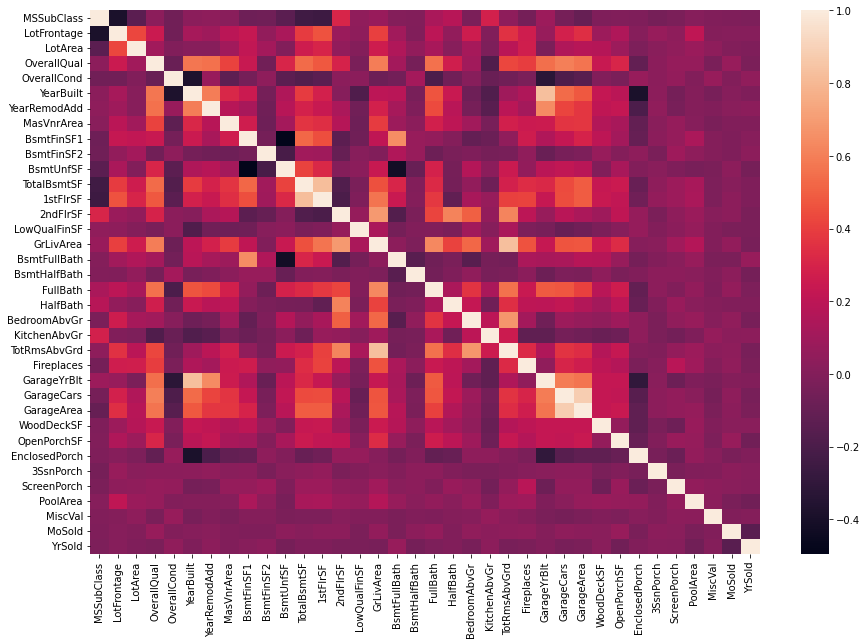

In [12]:
plt.figure(figsize=(15,10))
sns.heatmap(corr );

In [13]:
df_new.drop(columns = ["EnclosedPorch","LotFrontage","TotalBsmtSF", "1stFlrSF","GarageYrBlt","TotRmsAbvGrd","GarageCars",
                       "BsmtUnfSF", "GrLivArea"], inplace= True)
df_new.shape

(1460, 67)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  This is separate from the ipykernel package so we can avoid doing imports until


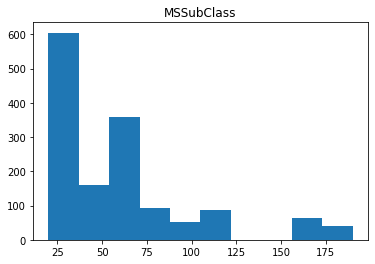

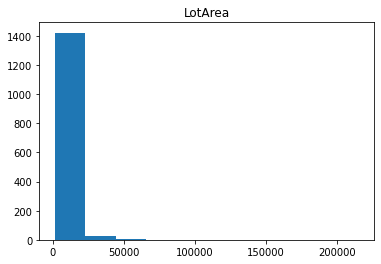

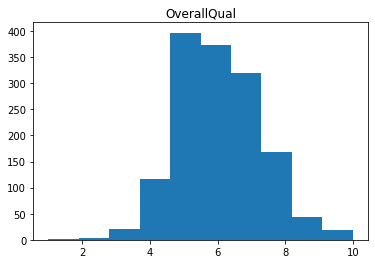

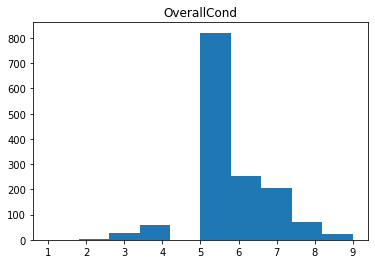

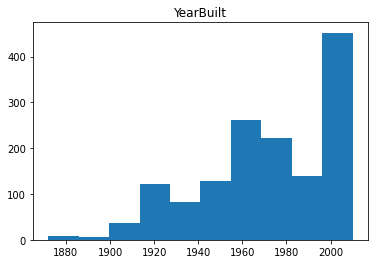

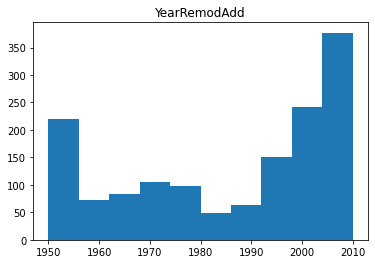

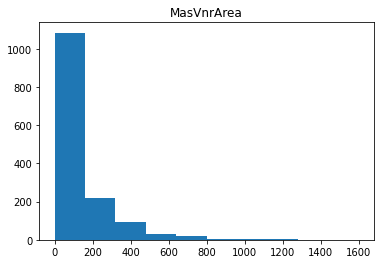

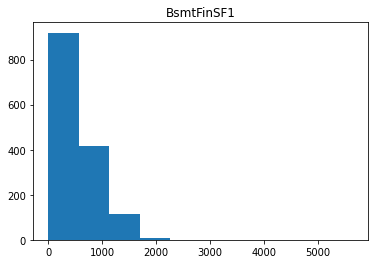

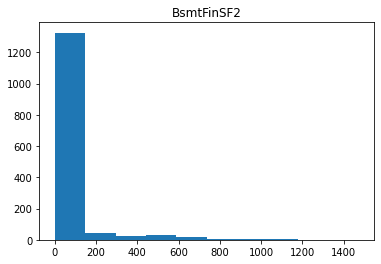

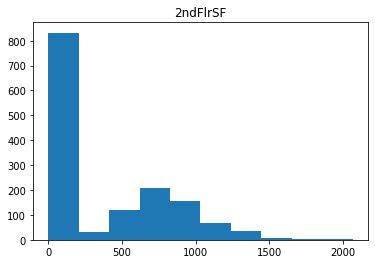

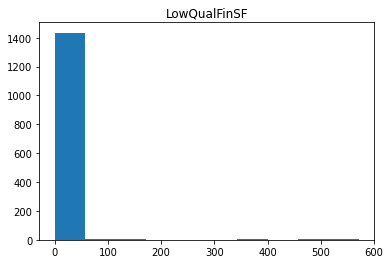

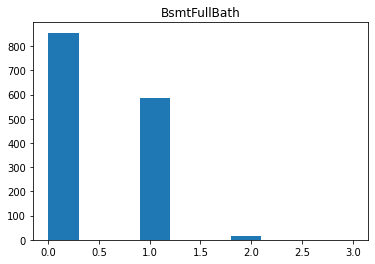

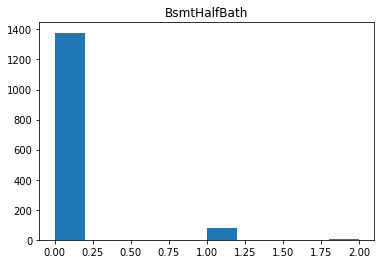

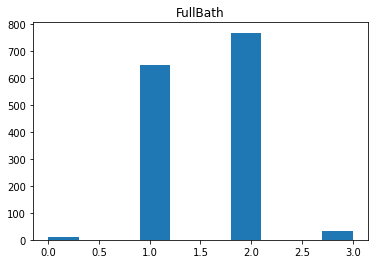

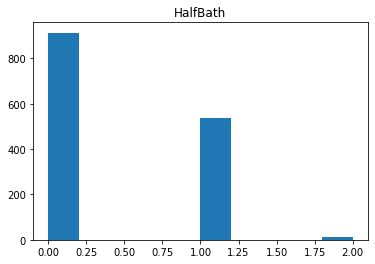

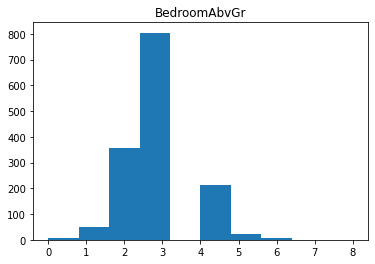

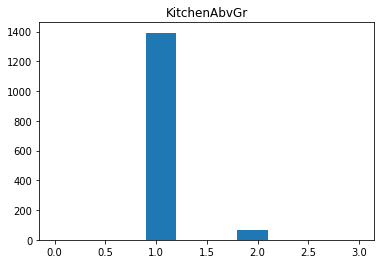

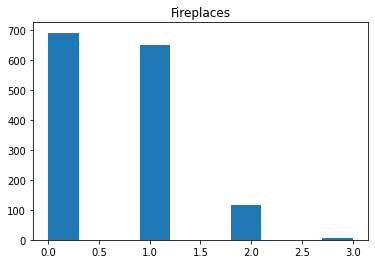

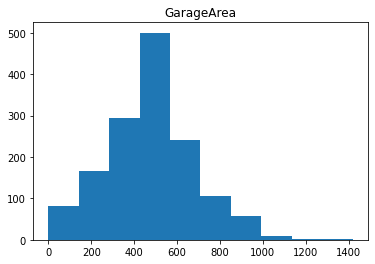

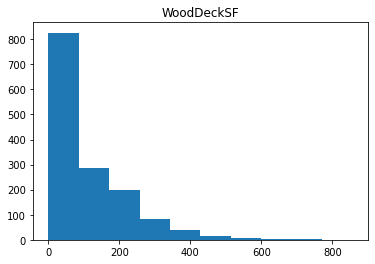

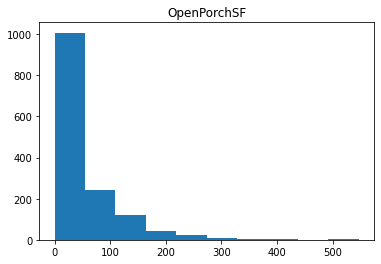

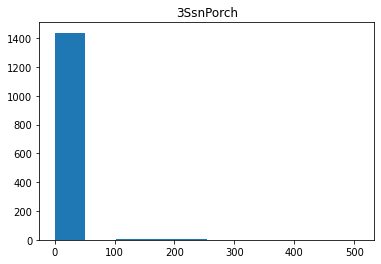

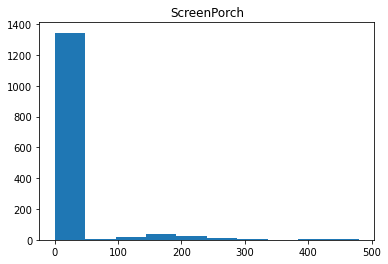

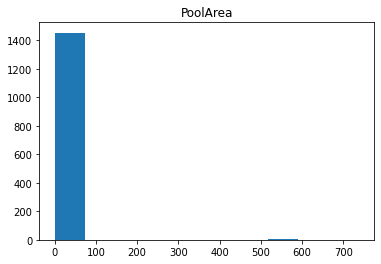

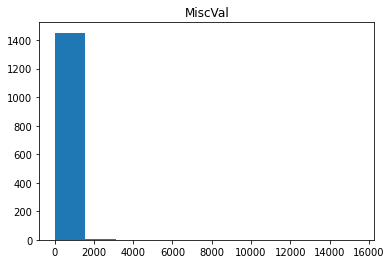

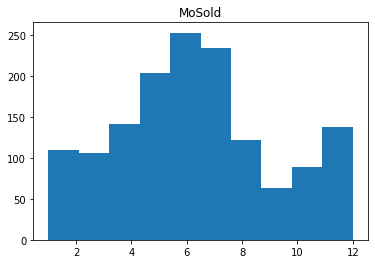

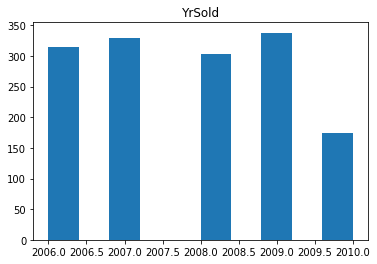

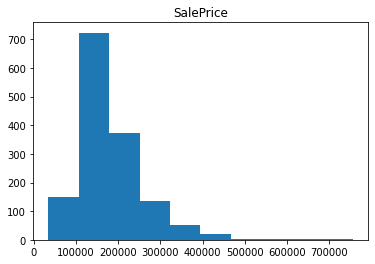

In [14]:
for i in df_new.select_dtypes("number").columns:
    
    plt.figure()
    plt.title(f'{i}')
    plt.hist(df_new[i]);

In [15]:
df_new.drop(columns = ["MiscVal","PoolArea","ScreenPorch", "3SsnPorch","BsmtHalfBath","LowQualFinSF"], inplace= True)
df_new.shape

(1460, 61)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  This is separate from the ipykernel package so we can avoid doing imports until


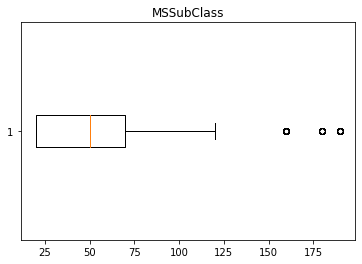

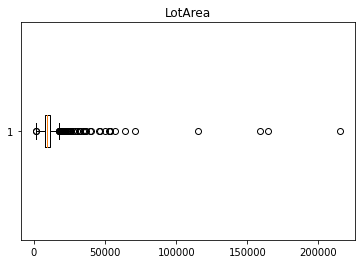

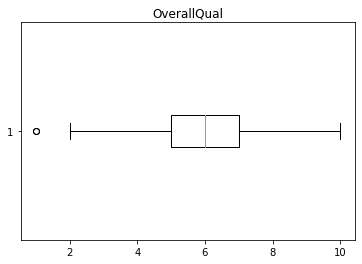

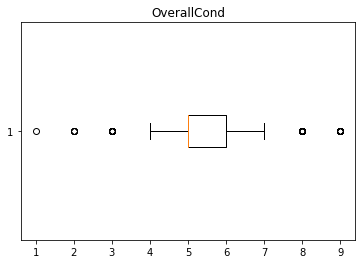

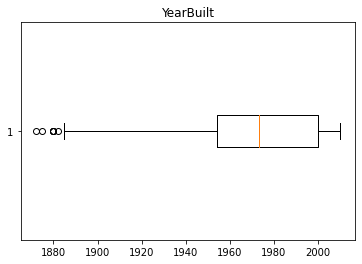

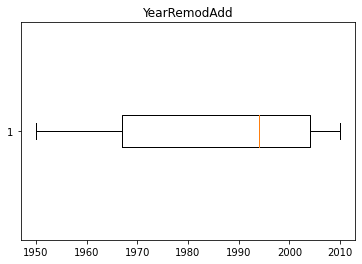

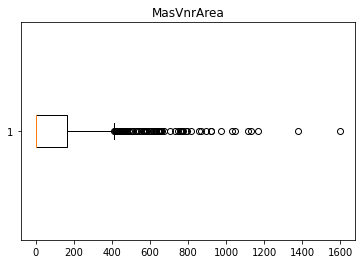

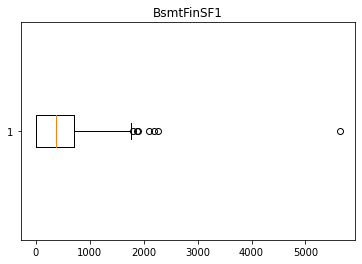

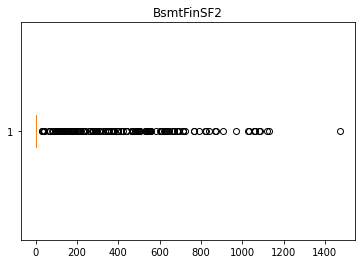

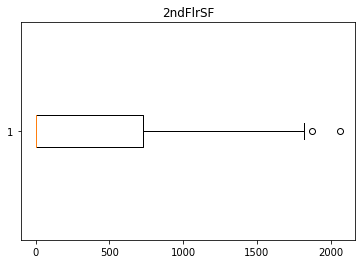

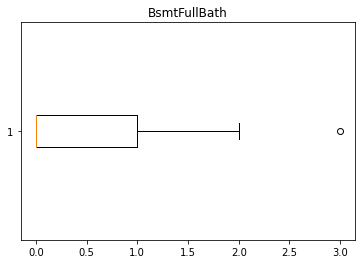

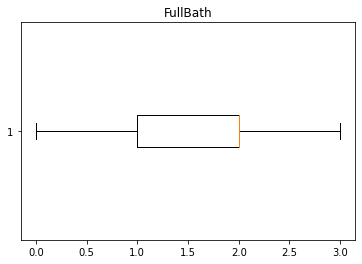

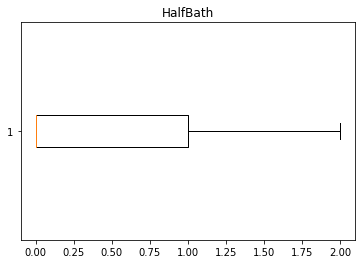

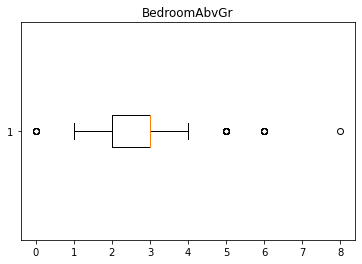

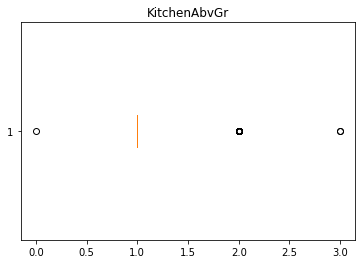

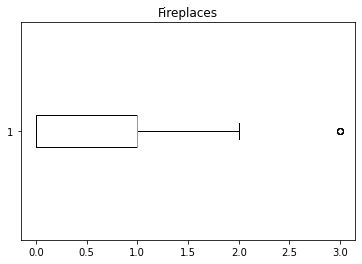

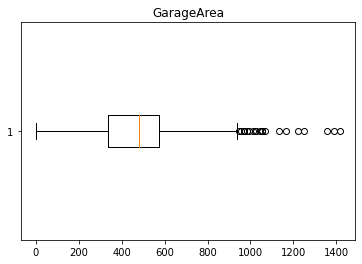

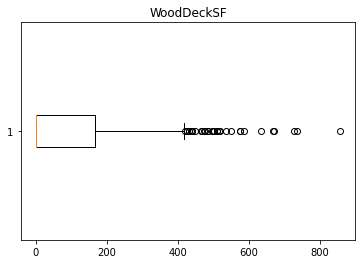

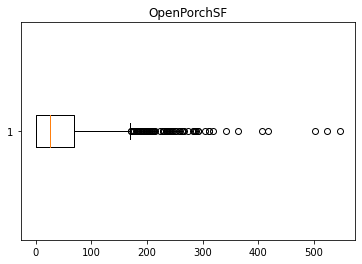

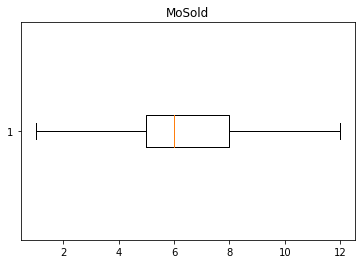

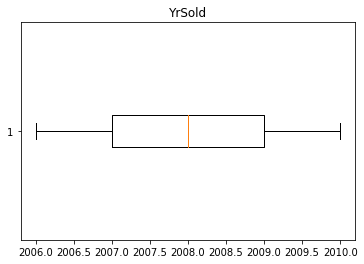

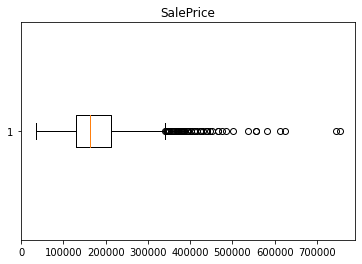

In [16]:
for i in df_new.select_dtypes("number").columns:
    
    plt.figure()
    plt.title(f'{i}')
    plt.boxplot(df_new[i], vert=False);

In [17]:
def plot_boxplot(df,ft):
    df.boxplot(column =[ft], vert = False)
    plt.grid(False)
    plt.show()

In [18]:
def outliers(df, ft):
    Q1 = df[ft].quantile(0.25)
    Q3 = df[ft].quantile(0.75)
    IQR = Q3-Q1
    
    low = Q1 - 1.5 * IQR
    top = Q3 + 1.5 * IQR
    
    ls = df.index[ (df[ft] < low ) |  (df[ft]  > top) ]
    return ls
    

In [19]:
index_list = []
for i in ["OpenPorchSF", "WoodDeckSF","GarageArea", "Fireplaces", "KitchenAbvGr", "BedroomAbvGr", "BsmtFullBath", "2ndFlrSF",
          "BsmtFinSF2" , "BsmtFinSF1", "MasVnrArea", "YearBuilt", "OverallCond", "OverallQual", "LotArea", "MSSubClass", "SalePrice"]:
    index_list.extend(outliers(df_new, i))


In [20]:
def remove (df, ls):
    ls = sorted(set(ls))
    df = df.drop(ls)
    return df

In [21]:
df_cleaned = remove(df_new, index_list)

In [22]:
df_cleaned.shape

(845, 61)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  This is separate from the ipykernel package so we can avoid doing imports until


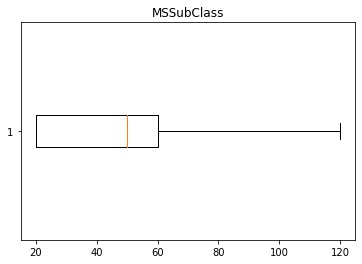

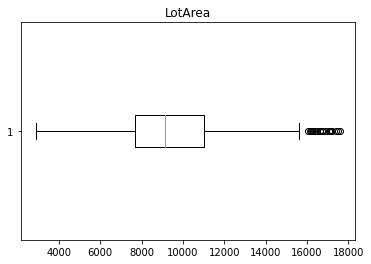

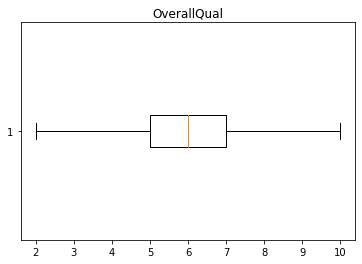

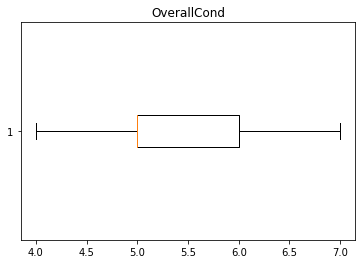

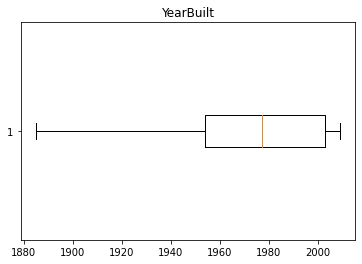

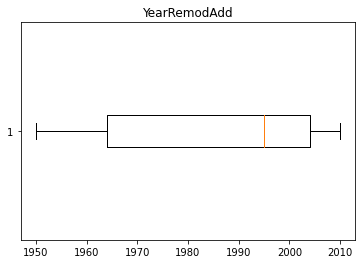

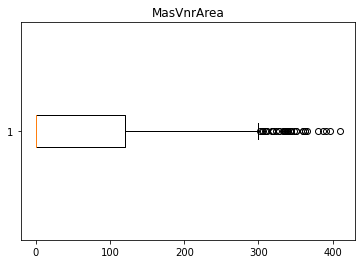

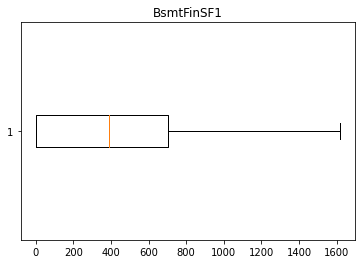

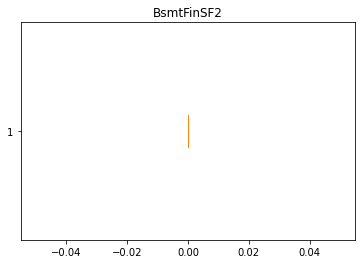

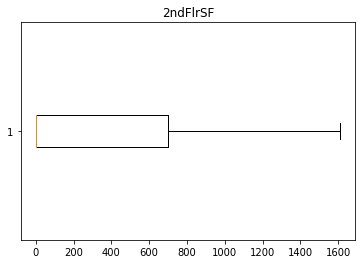

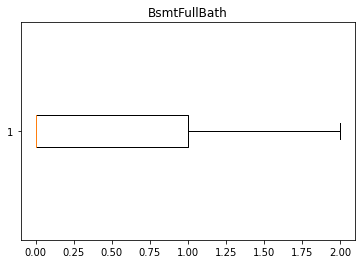

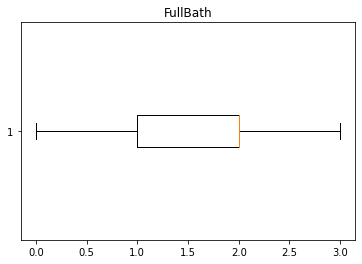

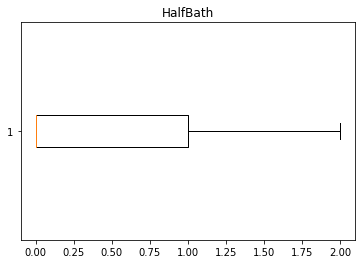

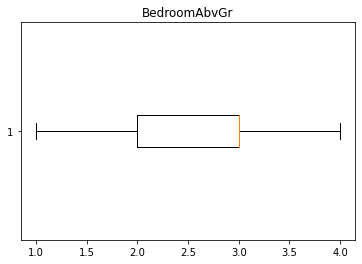

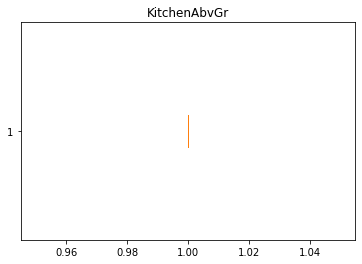

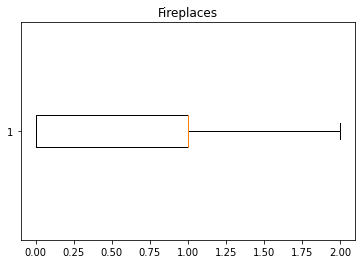

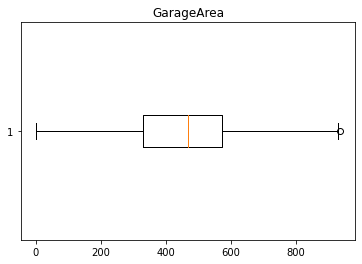

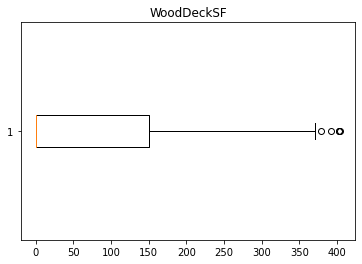

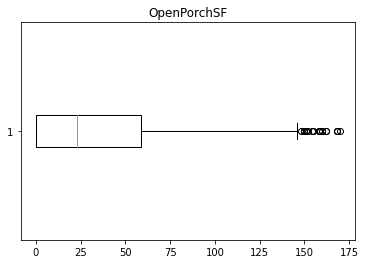

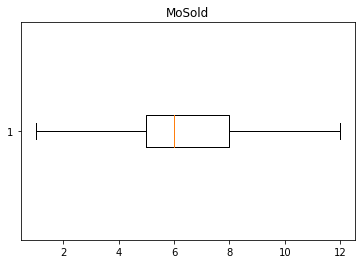

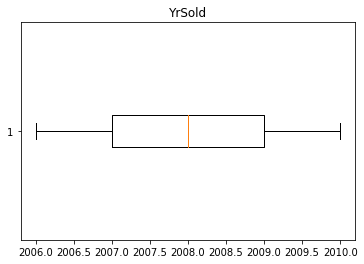

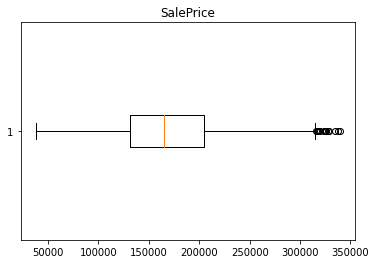

In [23]:
for i in df_cleaned.select_dtypes("number").columns:
    
    plt.figure()
    plt.title(f'{i}')
    plt.boxplot(df_cleaned[i], vert=False);

In [24]:
df_without_outliers = df_cleaned.reset_index()

df_without_outliers = df_cleaned.rename(columns={'index':'old_index'})
df_without_outliers

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,2ndFlrSF,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60.0,8450.0,7.0,5.0,2003.0,2003.0,196.0,706.0,0.0,854.0,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
2,60.0,11250.0,7.0,5.0,2001.0,2002.0,162.0,486.0,0.0,866.0,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,70.0,9550.0,7.0,5.0,1915.0,1970.0,0.0,216.0,0.0,756.0,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,0.0,1053.0,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
5,50.0,14115.0,5.0,5.0,1993.0,1995.0,0.0,732.0,0.0,566.0,...,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448,50.0,11767.0,4.0,7.0,1910.0,2000.0,0.0,0.0,0.0,550.0,...,TA,Min2,Gd,Detchd,Unf,Fa,TA,Y,WD,Normal
1451,20.0,9262.0,8.0,5.0,2008.0,2009.0,194.0,0.0,0.0,0.0,...,Ex,Typ,Gd,Attchd,Fin,TA,TA,Y,New,Partial
1453,20.0,17217.0,5.0,5.0,2006.0,2006.0,0.0,0.0,0.0,0.0,...,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,WD,Abnorml
1454,20.0,7500.0,7.0,5.0,2004.0,2005.0,0.0,410.0,0.0,0.0,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal


In [25]:
target = "SalePrice"
y = df_cleaned[target]
X= df_cleaned.drop(columns =target)

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.20, random_state = 42)

In [27]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

In [28]:
print("Mean Sale Price:", y_train.mean())
print("Mean Baseline:", mae_baseline)

Mean Sale Price: 172294.4349112426
Mean Baseline: 44829.27142782115


In [29]:
model = make_pipeline(OneHotEncoder(use_cat_names = True), Ridge())

In [30]:
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['MSZoning', 'Street', 'LotShape',
                                     'LandContour', 'Utilities', 'LotConfig',
                                     'LandSlope', 'Neighborhood', 'Condition1',
                                     'Condition2', 'BldgType', 'HouseStyle',
                                     'RoofStyle', 'RoofMatl', 'Exterior1st',
                                     'Exterior2nd', 'MasVnrType', 'ExterQual',
                                     'ExterCond', 'Foundation', 'BsmtQual',
                                     'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                     'BsmtFinType2', 'Heating', 'HeatingQC',
                                     'CentralAir', 'Electrical', 'KitchenQual', ...],
                               use_cat_names=True)),
                ('ridge', Ridge())])

In [31]:
y_pred = model.predict(X_test)
y_pred[:5]

array([184809.95069251, 121376.62262333, 139367.14928708,  61466.88821163,
       188875.83477202])

In [32]:
model.score(X_test, y_test)

0.8925066960173091

In [33]:
training_mae = mean_absolute_error(y_train,model.predict(X_train))
test_mae = mean_absolute_error(y_test,model.predict(X_test))
print("Training MAE:", training_mae)
print ("Test MAE:", test_mae)

Training MAE: 10866.95091938182
Test MAE: 13598.118454723344


In [34]:
df_test_data = pd.read_csv("../input/testnewdata/testnew.csv")
df_test_data.shape

(1459, 60)

In [35]:
y_pred = model.predict(df_test_data)
y_pred[:5]

array([127659.11344718, 160778.23005988, 186068.38365687, 186641.37230071,
       187195.40013584])